In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv('data/spam.csv',encoding='latin-1')
df=df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'], axis=1)
df=df.rename(columns={'v1':'label','v2':'message'})
print(df.shape)
df.head()

(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
print(df['label'].value_counts())
print("\nSpam Percentage:", round(df['label'].value_counts()['spam']/len(df)*100,2),"%")
print("\nHam Percentage:", round(df['label'].value_counts()['ham']/len(df)*100,2),"%")

label
ham     4825
spam     747
Name: count, dtype: int64

Spam Percentage: 13.41 %

Ham Percentage: 86.59 %


C:\Users\tkmma\AppData\Local\Temp\ipykernel_9056\919490128.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df,palette='viridis')


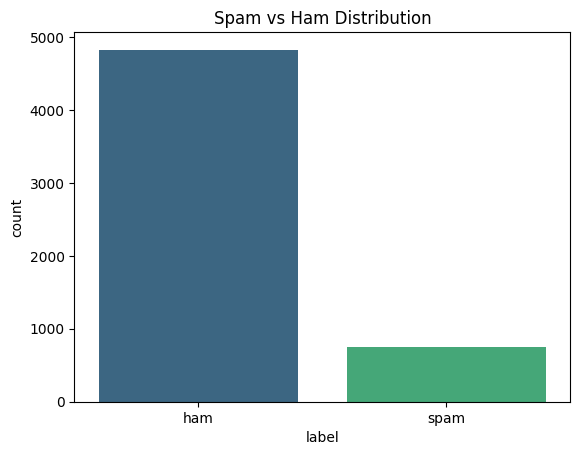

In [9]:
sns.countplot(x='label', data=df,palette='viridis')
plt.title('Spam vs Ham Distribution')
plt.show()

In [14]:
df['msg_length']=df['message'].apply(len)
print(df.groupby('label')['msg_length'].mean())

label
ham      71.023627
spam    138.866131
Name: msg_length, dtype: float64


In [15]:
print(df)

     label                                            message  msg_length
0      ham  Go until jurong point, crazy.. Available only ...         111
1      ham                      Ok lar... Joking wif u oni...          29
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...         155
3      ham  U dun say so early hor... U c already then say...          49
4      ham  Nah I don't think he goes to usf, he lives aro...          61
...    ...                                                ...         ...
5567  spam  This is the 2nd time we have tried 2 contact u...         161
5568   ham              Will Ì_ b going to esplanade fr home?          37
5569   ham  Pity, * was in mood for that. So...any other s...          57
5570   ham  The guy did some bitching but I acted like i'd...         125
5571   ham                         Rofl. Its true to its name          26

[5572 rows x 3 columns]


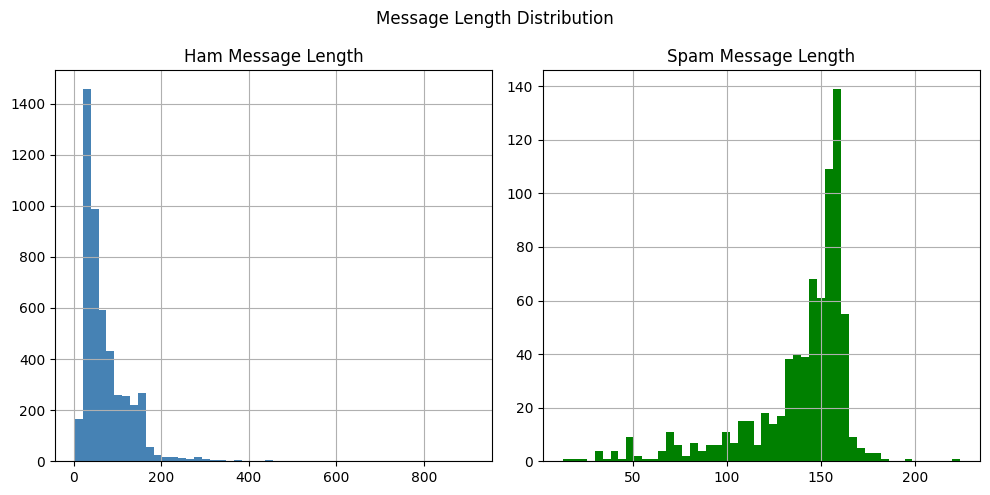

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

df[df['label']=='ham']['msg_length'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Ham Message Length')

df[df['label']=='spam']['msg_length'].hist(bins=50, ax=axes[1], color='green')
axes[1].set_title('Spam Message Length')

plt.suptitle('Message Length Distribution')
plt.tight_layout()
plt.show()

In [20]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tkmma\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tkmma\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tkmma\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Initialize stemmer and stopwords
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # Step 1 - Lowercase
    text = text.lower()
    
    # Step 2 - Removes punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Step 3 - Tokenize
    tokens = word_tokenize(text)
    
    # Step 4 - Removes stopwords and Step 5 - Stem
    tokens = [ps.stem(word) for word in tokens if word not in stop_words]
    
    # Join back into a string
    return ' '.join(tokens)

In [22]:
# Test on a spam message
sample = "FREE entry in 2 a wkly comp to WIN FA Cup final tkts 21st May 2005!"
print(preprocess(sample))

free entri wkli comp win fa cup final tkt st may


In [23]:
df['cleaned'] = df['message'].apply(preprocess)
print(df[['message', 'cleaned']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                             cleaned  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri wkli comp win fa cup final tkt st m...  
3                u dun say earli hor u c alreadi say  
4          nah dont think goe usf live around though  


In [24]:
print(df)

     label                                            message  msg_length  \
0      ham  Go until jurong point, crazy.. Available only ...         111   
1      ham                      Ok lar... Joking wif u oni...          29   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...         155   
3      ham  U dun say so early hor... U c already then say...          49   
4      ham  Nah I don't think he goes to usf, he lives aro...          61   
...    ...                                                ...         ...   
5567  spam  This is the 2nd time we have tried 2 contact u...         161   
5568   ham              Will Ì_ b going to esplanade fr home?          37   
5569   ham  Pity, * was in mood for that. So...any other s...          57   
5570   ham  The guy did some bitching but I acted like i'd...         125   
5571   ham                         Rofl. Its true to its name          26   

                                                cleaned  
0     go jurong p

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=3000)
X=tfidf.fit_transform(df['cleaned'])
y=df['label']
print('Shape of X:',X.shape)
print('Shape of y:',y.shape)

Shape of X: (5572, 3000)
Shape of y: (5572,)


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Training size:',X_train.shape)
print('Testing size:',X_test.shape)

Training size: (4457, 3000)
Testing size: (1115, 3000)


In [28]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train, y_train)
print('Model trained successfully!')

Model trained successfully!


In [29]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



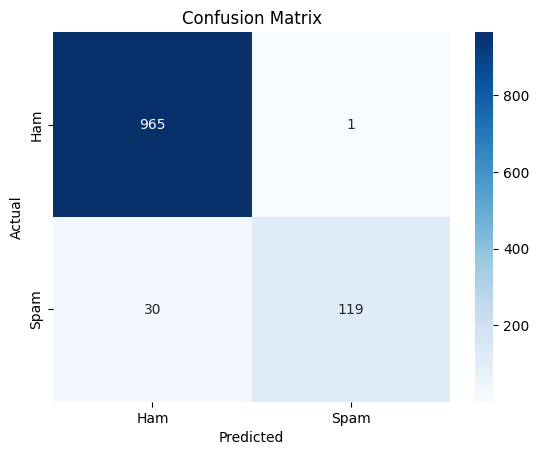

In [30]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix'),
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [31]:
import joblib
joblib.dump(model, 'model/spam_model.pkl')
joblib.dump(tfidf, 'model/tfidf_vectorizer.pkl')
print('Model and vectorizer saved successfully!')

Model and vectorizer saved successfully!
